Inicjalizacja Projektu: Klasyfikacja ryzyka opóźnienia dostawy

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.59      0.63      0.61     24463
           1       0.68      0.64      0.66     29693

    accuracy                           0.64     54156
   macro avg       0.64      0.64      0.64     54156
weighted avg       0.64      0.64      0.64     54156


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.62      0.82      0.71     24463
           1       0.80      0.59      0.68     29693

    accuracy                           0.69     54156
   macro avg       0.71      0.70      0.69     54156
weighted avg       0.72      0.69      0.69     54156

 Porównanie modeli 
Random Forest -> Precision: 0.68 | Recall: 0.64
Logistic Regression -> Precision: 0.80 | Recall: 0.59


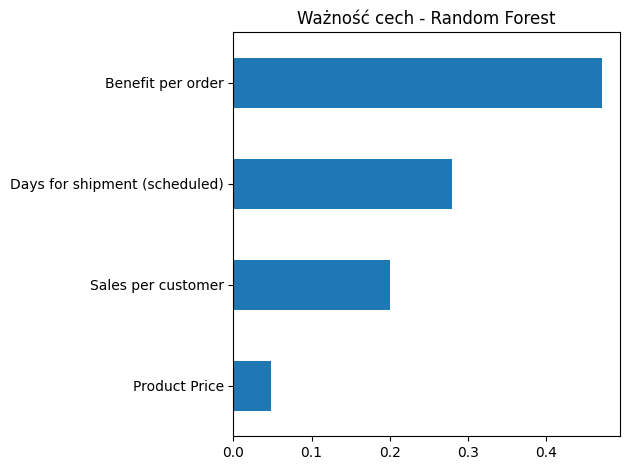

 Sprawdź konkretny produkt
Produkt: Baby sweater
Prognoza opóźnienia: NIE
Prawdopodobieństwo opóźnienia: 14%


In [8]:
import pandas as pd
import numpy as np
import time
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("Inicjalizacja Projektu: Klasyfikacja ryzyka opóźnienia dostawy")

# Wczytywanie danych
dataset = pd.read_csv(r'C:\Users\Alicja\Desktop\kurs-datascience\DataCoSupplyChainDataset.csv', encoding='latin1')

# Definiowanie zmiennych
y = dataset['Late_delivery_risk']

dane = [
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Sales per customer',
    'Product Price'
]
X = dataset[dane]

# Wypełnienie braków danych za pomocą mediany
X = X.fillna(X.median())

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Słownik na wyniki
precision_results = {}
recall_results = {}

# Modele do porównania
modele = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

# Trenowanie i ewaluacja
for nazwa, model in modele.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    precision_results[nazwa] = precision_score(y_test, y_pred)
    recall_results[nazwa] = recall_score(y_test, y_pred)
    
    print(f"\n--- {nazwa} ---")
    print(classification_report(y_test, y_pred))

# Podsumowanie
print(" Porównanie modeli ")
for nazwa in modele:
    print(f"{nazwa} -> Precision: {precision_results[nazwa]:.2f} | Recall: {recall_results[nazwa]:.2f}")

# Wykres ważności cech (tylko Random Forest)
import matplotlib.pyplot as plt

rf_model = modele['Random Forest']
importance = pd.Series(rf_model.feature_importances_, index=dane)
importance.sort_values().plot(kind='barh', title='Ważność cech - Random Forest')
plt.tight_layout()
plt.show()

# Prognoza dla konkretnego zamówienia 
print(" Sprawdź konkretny produkt")

nazwa_produktu = "Baby sweater"  

dostepne_produkty = dataset['Product Name'].unique()

if nazwa_produktu not in dostepne_produkty:
    print(f"Produkt '{nazwa_produktu}' nie istnieje w datasecie.")
    print("Dostępne produkty (pierwsze 10):")
    print(list(dostepne_produkty[:10])) # Wyświetlam tylko 10, żeby nie zasypać konsoli
else:
    # Wyciągamy dane tylko dla tego produktu
    produkt_dane = dataset[dataset['Product Name'] == nazwa_produktu]
    
    nowe_zamowienie = pd.DataFrame([{
        'Days for shipment (scheduled)': produkt_dane['Days for shipment (scheduled)'].median(),
        'Benefit per order': produkt_dane['Benefit per order'].median(),
        'Sales per customer': produkt_dane['Sales per customer'].median(),
        'Product Price': produkt_dane['Product Price'].median()
    }])
    
    # Przekształcenie danych i predykcja
    nowe_zamowienie_scaled = scaler.transform(nowe_zamowienie)
    wynik = modele['Random Forest'].predict(nowe_zamowienie_scaled)
    prawdopodobienstwo = modele['Random Forest'].predict_proba(nowe_zamowienie_scaled)[0][1]
    
    print(f"Produkt: {nazwa_produktu}")
    print(f"Prognoza opóźnienia: {'TAK' if wynik[0] == 1 else 'NIE'}")
    print(f"Prawdopodobieństwo opóźnienia: {prawdopodobienstwo:.0%}")